In [267]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os

In [268]:

if __name__ == '__main__':

    path = "../data-resampled/"

    hour_clock = []

    q = 0
    for root, dir, files in os.walk(path):
        
        for file in files:
            hour_real = file[6:8]
            minute_real = file[8:10]
            hour_clock.append(cv.cvtColor(cv.imread(os.path.join(root,file)), cv.COLOR_BGR2GRAY))
            q+=1
            if q == 20:
                break

        break




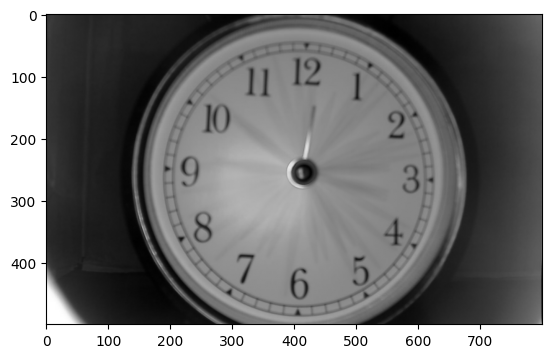

In [269]:

stacked = np.stack(hour_clock, axis=0)

overlay = np.mean(stacked, axis=0)


plt.imshow(overlay, cmap="gray")

Después de haber realizado nuestro template lo que hacemos es comenzar el preprocesamiento de la imagen que vamos a leer.

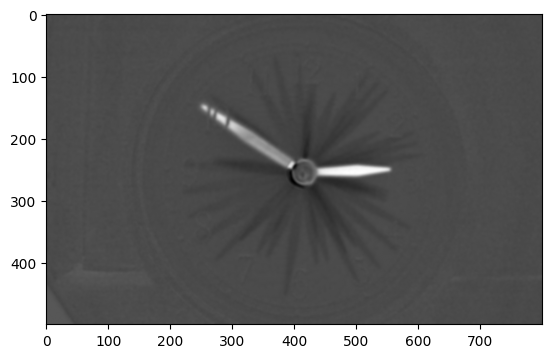

In [270]:
# Para reducir ruido aplicamos blur tanto en el overlay como en la imagen a leer.

im = cv.cvtColor(cv.imread("../data-resampled/clock_0250.png"), cv.COLOR_BGR2GRAY)


kernel_size = (5,5)


im = cv.GaussianBlur(im, kernel_size,2)



overlay = cv.GaussianBlur(overlay, kernel_size, 2)


clock_hands = overlay - im

plt.imshow(clock_hands, cmap="gray")



# Detectar circulo

In [271]:
circles = cv.HoughCircles(im.astype(np.uint8), cv.HOUGH_GRADIENT, 1, 20, param1=10, param2=50, minRadius=220, maxRadius=225)
circles

array([[[412.5, 263.5, 224.4]]], dtype=float32)

In [272]:
canny_copy = im.copy()
for c in circles[0]:
    (x,y,r) = c
    x = int(x)
    y = int(y)
    r = int(r)
    cv.circle(canny_copy, (x, y), r, (255, 255, 255), 8)

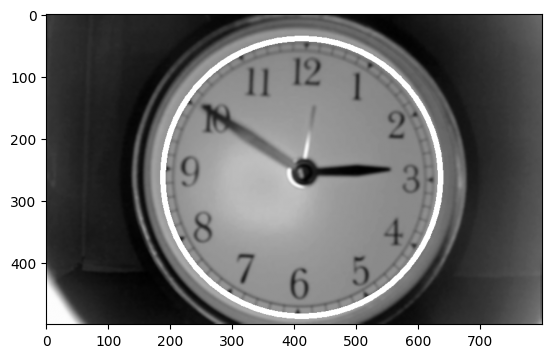

In [273]:
plt.imshow(canny_copy, cmap="gray")
plt.show()

# Umbralization!


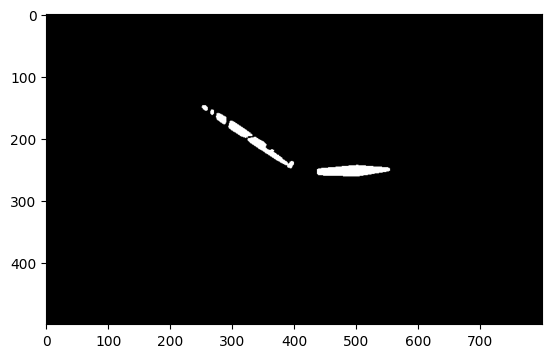

In [274]:
def umbralization(img,t, option1, option2):
    M,N = img.shape

    result = np.zeros((M,N))

    for i in range(M):
        for j in range(N):
            result[i,j] = option1 if img[i,j]  <= t  else option2


    return result



umbralized = 255 - umbralization(clock_hands,40, 255, 0) 
plt.imshow(umbralized, cmap="gray")
plt.show()

224, 412 263


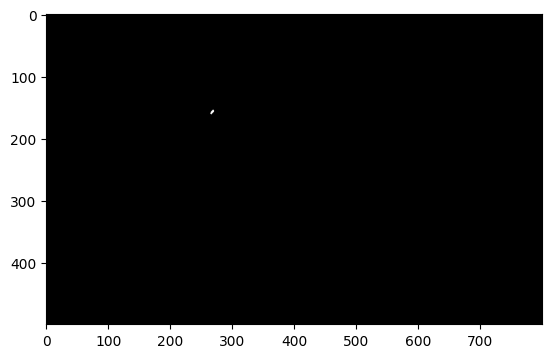

In [ ]:
x_centro = int(circles[0][0][0])
y_centro = int(circles [0][0][1])
radio = int(circles[0][0][2])

center = (x_centro, y_centro)

circle_1_minutes = np.zeros((im.shape))

cv.circle(circle_1_minutes, center, int(radio*0.8),(255,0,0), 2)
minutes = np.multiply(circle_1_minutes, umbralized)

plt.imshow(minutes, cmap="gray")


print(f"{radio}, {x_centro} {y_centro}")


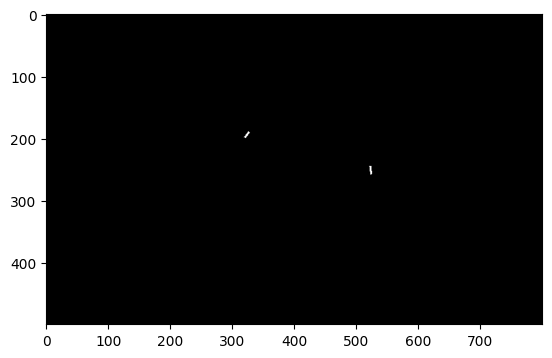

In [277]:
circle_2_hours = np.zeros((im.shape))
cv.circle(circle_2_hours, center, int(radio*0.5),(255,255,255), 2)
hours = circle_2_hours*umbralized
plt.imshow(hours, cmap="gray")



# Hallamos los minutos

In [278]:
y_minutes, x_minutes = np.where(minutes > 0)

distance = np.sqrt((x_minutes-x_centro)**2 + (y_minutes-y_centro)**2)

manecilla_grande_idx = np.argmax(distance)

In [279]:
x_punta_g, y_punta_g = x_minutes[manecilla_grande_idx], y_minutes[manecilla_grande_idx]


dy =  (x_punta_g - x_centro)
dx =  (y_centro - y_punta_g)

theta = np.degrees(np.arctan2(dy, dx) + 360)%360

theta_clock = (90 - theta) % 360

minute_output = (theta_clock /6) % 60
minute_output

np.float64(6.256449620290975)

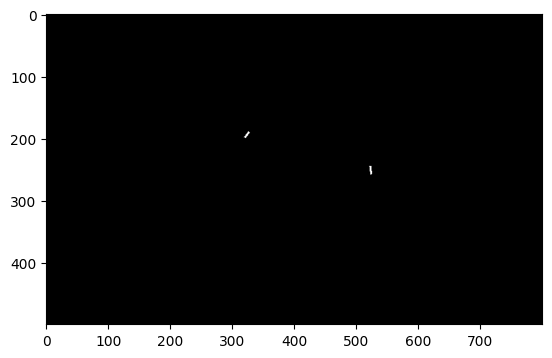

In [280]:
test = hours.copy()

cv.circle(test, (int(y_punta_g), int(x_punta_g)), 70,0, -1)
plt.imshow(test, cmap="gray")

# Hallamos las horas.

In [281]:
y,x = np.where(test > 0)

distance = np.sqrt((x - x_centro)**2 + (y - y_centro)**2)

manecilla_pequeña_idx = np.argmax(distance)



In [282]:

x_punta, y_punta = x[manecilla_pequeña_idx], y[manecilla_pequeña_idx]

dx = x_punta - x_centro
dy = y_centro - y_punta  
theta = (np.degrees(np.arctan2(dy, dx)) + 360) % 360
theta_from_12 = (90 - theta) % 360
hour = (theta_from_12 / 30) % 12





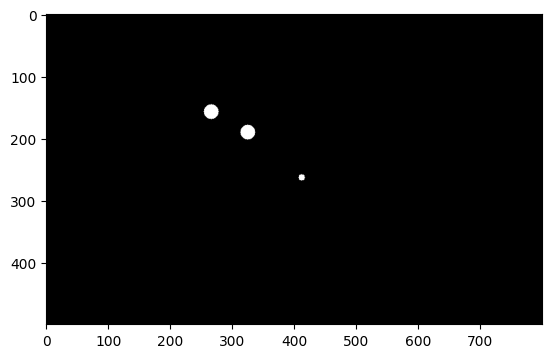

In [283]:
test = np.zeros(im.shape, dtype=np.uint8)

cv.circle(test, (int(x_punta_g), int(y_punta_g)), 12, (255,255,255), -1)
cv.circle(test, (int(x_punta), int(y_punta)), 12, (255,255,255), -1)
cv.circle(test, (int(x_centro), int(y_centro)), 5, (255,255,255), -1)

plt.imshow(test, cmap="gray")

In [284]:
print(f"{x_punta_g}, {y_punta_g}")

266, 157


In [285]:
print(f"La hora es {hour} {minute_output}")

La hora es 10.333311846748051 6.256449620290975
